# Module 13 – EDA Report



## 1. Dataset Overview

This section gives a basic overview of the dataset, including its size, features, target variable, and domain.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/hotel_bookings.csv")

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [8]:
print("Dataset Shape:", df.shape)

print("\nNumber of Features:", len(df.columns))

print("\nFeatures:")
print(df.columns.tolist())

print("\nTarget Variable: is_canceled")

print("\nDomain: Hotel Booking")

Dataset Shape: (119390, 32)

Number of Features: 32

Features:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

Target Variable: is_canceled

Domain: Hotel Booking


## 2. Data Quality

This section checks the dataset for missing values, duplicate records, invalid values, and data type issues.

In [9]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Missing Values:
hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340


## 3. Statistical Findings

This section summarizes the numerical features using central tendency, dispersion, distribution, and outlier analysis.

In [3]:
# Central tendency and dispersion
display(df.describe())

# Distribution
print("Skewness:")
display(df.select_dtypes(include="number").skew().sort_values())

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


Skewness:


arrival_date_year                 -0.232583
arrival_date_week_number          -0.010014
arrival_date_day_of_month         -0.002000
is_canceled                        0.536678
company                            0.601600
agent                              1.089386
lead_time                          1.346550
total_of_special_requests          1.349189
stays_in_weekend_nights            1.380046
stays_in_week_nights               2.862249
children                           4.112590
required_car_parking_spaces        4.163233
is_repeated_guest                  5.326315
booking_changes                    6.000270
adr                               10.530214
days_in_waiting_list              11.944353
adults                            18.317805
previous_bookings_not_canceled    23.539800
previous_cancellations            24.458049
babies                            24.646545
dtype: float64

### Outliers

Outliers were checked in the numerical features using the IQR method.

In [4]:
# Outlier check using IQR
num_df = df.select_dtypes(include="number")

Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((num_df < (Q1 - 1.5 * IQR)) |
            (num_df > (Q3 + 1.5 * IQR))).sum()

display(outliers.sort_values(ascending=False))

adults                            29710
booking_changes                   18076
children                           8590
required_car_parking_spaces        7416
previous_cancellations             6484
is_repeated_guest                  3810
adr                                3793
days_in_waiting_list               3698
previous_bookings_not_canceled     3620
stays_in_week_nights               3354
lead_time                          3005
total_of_special_requests          2877
babies                              917
stays_in_weekend_nights             265
is_canceled                           0
arrival_date_year                     0
arrival_date_week_number              0
arrival_date_day_of_month             0
company                               0
agent                                 0
dtype: int64

## 4. Relationship Findings

This section examines the relationships between important features and identifies patterns that may be useful for further analysis.

In [5]:
# Correlation between numerical features
correlation = df.select_dtypes(include="number").corr()

display(correlation)

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
is_canceled,1.000000,0.293123,0.016660,0.008148,-0.006130,-0.001791,0.024765,0.060017,0.005048,-0.032491,-0.084793,0.110133,-0.057358,-0.144381,-0.083114,-0.020642,0.054186,0.047557,-0.195498,-0.234658
lead_time,0.293123,1.000000,0.040142,0.126871,0.002268,0.085671,0.165799,0.119519,-0.037622,-0.020915,-0.124410,0.086042,-0.073548,0.000149,-0.069741,0.151464,0.170084,-0.063077,-0.116451,-0.095712
arrival_date_year,0.016660,0.040142,1.000000,-0.540561,-0.000221,0.021497,0.030883,0.029635,0.054624,-0.013192,0.010341,-0.119822,0.029218,0.030872,0.063457,0.259095,-0.056497,0.197580,-0.013684,0.108531
arrival_date_week_number,0.008148,0.126871,-0.540561,1.000000,0.066809,0.018208,0.015558,0.025909,0.005518,0.010395,-0.030131,0.035501,-0.020904,0.005508,-0.031201,-0.076760,0.022933,0.075791,0.001920,0.026149
arrival_date_day_of_month,-0.006130,0.002268,-0.000221,0.066809,1.000000,-0.016354,-0.028174,-0.001566,0.014544,-0.000230,-0.006145,-0.027011,-0.000300,0.010613,0.001487,0.044858,0.022728,0.030245,0.008683,0.003062
stays_in_weekend_nights,-0.001791,0.085671,0.021497,0.018208,-0.016354,1.000000,0.498969,0.091871,0.045793,0.018483,-0.087239,-0.012775,-0.042715,0.063281,0.140739,0.066749,-0.054151,0.049342,-0.018554,0.072671
stays_in_week_nights,0.024765,0.165799,0.030883,0.015558,-0.028174,0.498969,1.000000,0.092976,0.044203,0.020191,-0.097245,-0.013992,-0.048743,0.096209,0.182382,0.182211,-0.002020,0.065237,-0.024859,0.068192
adults,0.060017,0.119519,0.029635,0.025909,-0.001566,0.091871,0.092976,1.000000,0.030447,0.018146,-0.146426,-0.006738,-0.107983,-0.051673,-0.035594,0.207793,-0.008283,0.230641,0.014785,0.122884
children,0.005048,-0.037622,0.054624,0.005518,0.014544,0.045793,0.044203,0.030447,1.000000,0.024030,-0.032859,-0.024730,-0.021072,0.048949,0.041066,0.030931,-0.033273,0.324854,0.056253,0.081745
babies,-0.032491,-0.020915,-0.013192,0.010395,-0.000230,0.018483,0.020191,0.018146,0.024030,1.000000,-0.008943,-0.007501,-0.006550,0.083440,0.036184,0.019206,-0.010621,0.029186,0.037383,0.097889


### Correlation Heatmap

The heatmap helps us identify which numerical features have stronger or weaker relationships with each other.

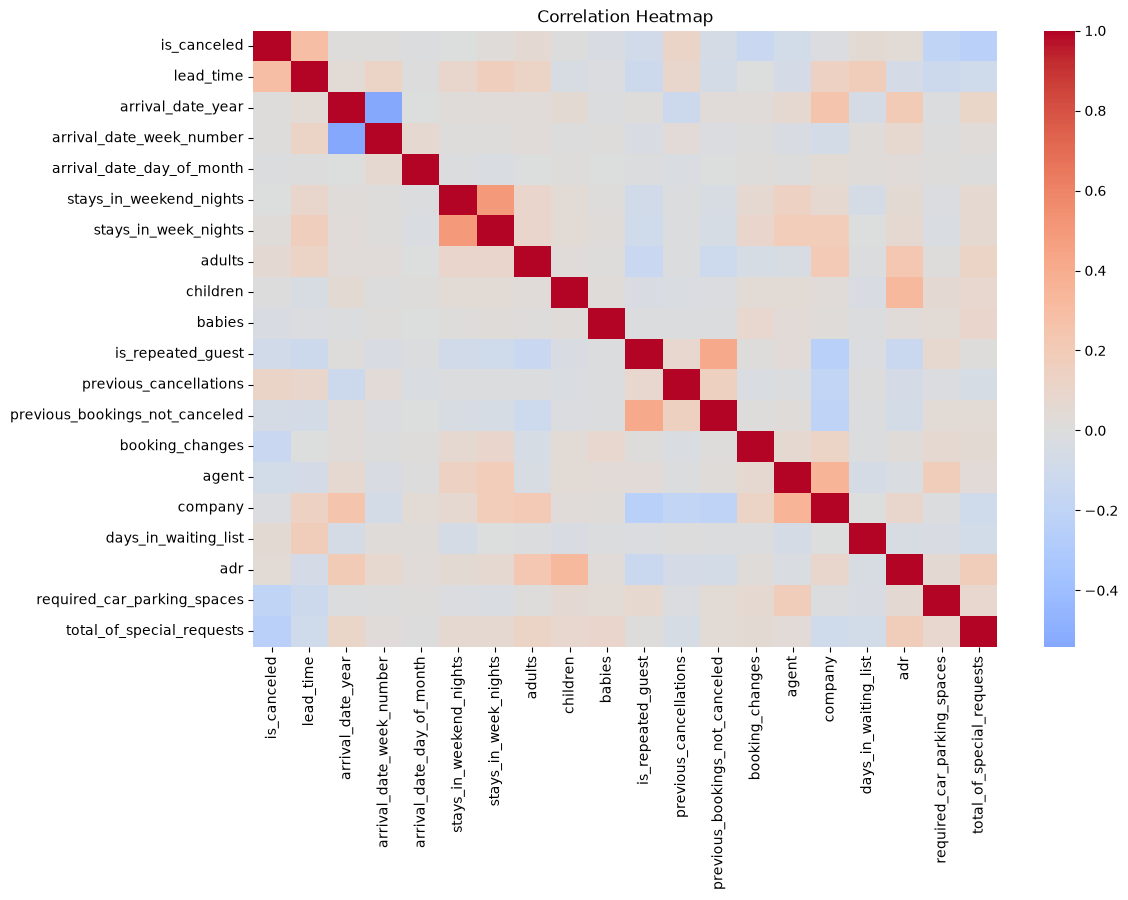

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

### Important Relationships

Based on the correlation results and the EDA performed earlier, important relationships between features are documented here.

Only relationships that show a meaningful pattern are considered for the next stage.

## 5. Visualization Findings

This section summarizes the important findings observed from the visualizations created during EDA.

The focus is on the main patterns and observations that may be useful for further analysis.

### Key Visual Findings

The visualizations helped identify differences in cancellation rates, customer behavior, booking patterns, and relationships between important features.

The most useful observations from the visual analysis are documented here for reference during the next stage.

## 6. Potential Data Problems

Based on the EDA, the following data problems may need to be addressed during the next preprocessing stage:

- Missing values
- Duplicate records
- Outliers in numerical features
- Inconsistent categorical values
- Incorrect data types
- Skewed numerical features
- Possible class imbalance in the target variable

These issues are identified for further treatment in the preprocessing stage.

In [8]:
# Summary of potential data problems

print("Missing values:")
display(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDuplicate records:", df.duplicated().sum())

print("\nNumerical columns:")
print(df.select_dtypes(include="number").columns.tolist())

print("\nCategorical columns:")
print(df.select_dtypes(include="object").columns.tolist())

Missing values:


children         4
country        488
agent        16340
company     112593
dtype: int64


Duplicate records: 31994

Numerical columns:
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


C:\Users\HP\AppData\Local\Temp\ipykernel_17256\1296611230.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include="object").columns.tolist())


## 7. Recommendations

Based on the EDA findings, the following steps can be considered during the next preprocessing stage:

- Handle missing values using a suitable method.
- Review and treat important outliers.
- Convert categorical features into a suitable format.
- Correct any data type issues.
- Apply scaling where required.
- Consider feature transformation for highly skewed features.
- Create useful features if needed.
- Check and handle target class imbalance if required.

The complete preprocessing will be performed in the next stage.